In [86]:
import numpy as np 
import matplotlib.pyplot as plt

In [87]:
dt = 0.04

g = 9.8
l = 1

np.sin(np.pi/2)

np.float64(1.0)

## Euler Method

In [88]:

# Storing array of time, omega and theta
t = np.arange(0, 10+dt, dt) 
omega = np.zeros(len(t))

theta = np.zeros(len(t))      
theta[0] = 0.2

for i in range(len(t)-1): 
    omega[i+1] = omega[i]- (g/l)*theta[i]*dt
    theta[i+1] = theta[i] + dt*omega[i]
    t[i+1] = t[i] + dt

## Euler-Cromer Method 


In [89]:
# Storing array of time, omega and theta
tC = np.arange(0, 10+dt, dt) 
omegaC = np.zeros(len(tC))

thetaC = np.zeros(len(tC))      
thetaC[0] = 0.2

for i in range(len(tC)-1): 
    omegaC[i+1] = omegaC[i]- (g/l)*thetaC[i]*dt
    thetaC[i+1] = thetaC[i] + dt*omegaC[i+1]
    tC[i+1] = tC[i] + dt

<function matplotlib.pyplot.show(close=None, block=None)>

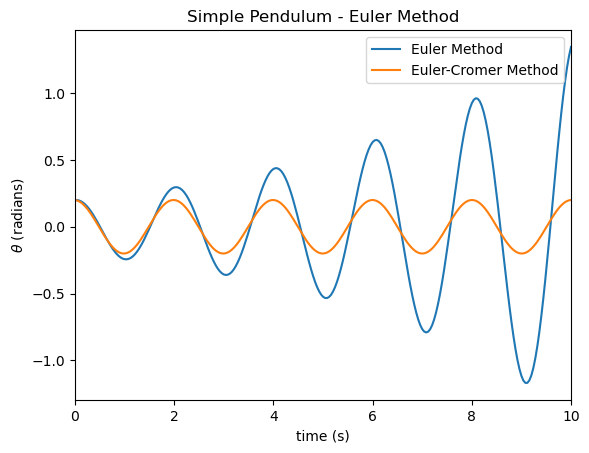

In [90]:
plt.plot(t, theta, label = 'Euler Method')
plt.plot(tC, thetaC, label = 'Euler-Cromer Method')

plt.xlabel('time (s)') 
plt.ylabel(r"$\theta$ (radians)") 
plt.title("Simple Pendulum - Euler Method") 
plt.legend()
plt.xlim(0,10)
plt.show

## Damping 


In [97]:
def SHMdamping (dt, g, l, q) : 
    t = np.arange(0, 20+dt, dt) 
    omega = np.zeros(len(t))
    
    theta = np.zeros(len(t))      
    theta[0] = 0.2
    
    for i in range(len(t)-1): 
        omega[i+1] = omega[i]- ((g/l)*theta[i]+q*omega[i])*dt
        theta[i+1] = theta[i] + dt*omega[i+1]
        t[i+1] = t[i] + dt

    return t, theta
    

In [98]:
# underdamped, q=1
t_underdamped, theta_underdamped = SHMdamping(dt,g,l,1)
t_overdamped, theta_overdamped = SHMdamping(dt,g,l,5)
t_criticallydamped, theta_criticallydamped = SHMdamping(dt,g,l,10)

<function matplotlib.pyplot.show(close=None, block=None)>

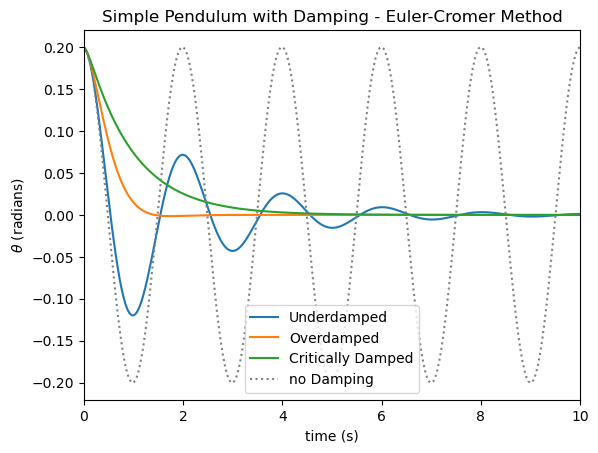

In [99]:
plt.plot(t_underdamped, theta_underdamped, label = 'Underdamped')
plt.plot(t_overdamped, theta_overdamped, label = 'Overdamped')
plt.plot(t_criticallydamped, theta_criticallydamped, label = 'Critically Damped')
plt.plot(tC, thetaC,'grey', linestyle ='dotted', label = 'no Damping')

plt.xlabel('time (s)') 
plt.ylabel(r"$\theta$ (radians)") 
plt.title("Simple Pendulum with Damping - Euler-Cromer Method") 
plt.legend()
plt.xlim(0,10)
plt.show

# Driving Force + Damping

In [124]:
def SHM_damping_and_drivenforce (dt, g, l, q, FD, omegaD) : 
    t = np.arange(0, 20+dt, dt) 
    omega = np.zeros(len(t))
    
    theta = np.zeros(len(t))      
    theta[0] = 0.2
    
    for i in range(len(t)-1): 
        omega[i+1] = omega[i]- ((g/l)*theta[i]+q*omega[i]-FD*np.sin(omegaD*t[i]))*dt
        theta[i+1] = theta[i] + dt*omega[i+1]
        t[i+1] = t[i] + dt

    return t, theta

t_DampedAndDriven, theta_DampedAndDriven = SHM_damping_and_drivenforce(dt,g,l,1,0.2,2)


<function matplotlib.pyplot.show(close=None, block=None)>

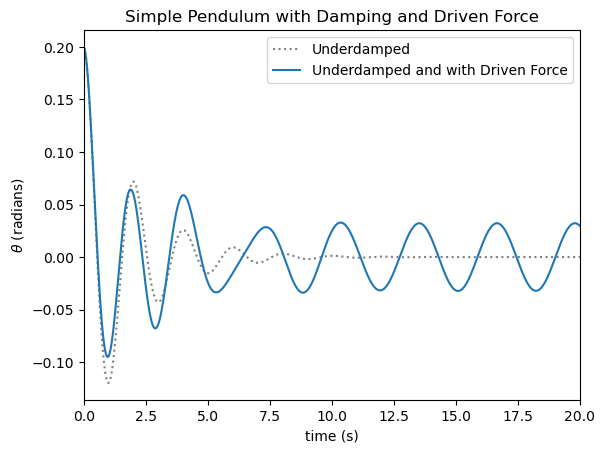

In [125]:
plt.plot(t_underdamped, theta_underdamped,'grey', linestyle ='dotted', label = 'Underdamped')
plt.plot(t_DampedAndDriven, theta_DampedAndDriven, label = 'Underdamped and with Driven Force')


plt.xlabel('time (s)') 
plt.ylabel(r"$\theta$ (radians)") 
plt.title("Simple Pendulum with Damping and Driven Force") 
plt.legend()
plt.xlim(0,20)
plt.show

In [120]:
def SHM_BigTheta (dt, g, l, theta0) : 
    t = np.arange(0, 20+dt, dt) 
    omega = np.zeros(len(t))
    
    theta = np.zeros(len(t))      
    theta[0] = theta0
    
    for i in range(len(t)-1): 
        omega[i+1] = omega[i]- (g/l)*np.sin(theta[i])*dt
        theta[i+1] = theta[i] + dt*omega[i+1]
        t[i+1] = t[i] + dt

    return t, theta
    
Bigt3, BigTheta3 = SHM_BigTheta(dt,g,l, 3)
Bigt1, BigTheta1 = SHM_BigTheta(dt,g,l, 1.5)

<function matplotlib.pyplot.show(close=None, block=None)>

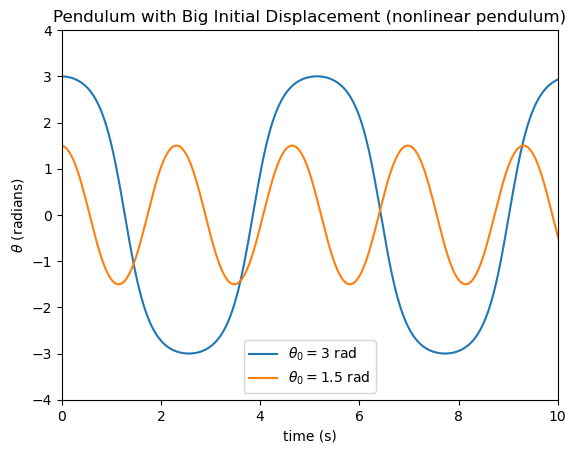

In [123]:
plt.plot(Bigt3, BigTheta3, label = r'$\theta_0 = 3$ rad')
plt.plot(Bigt1, BigTheta1, label = r'$\theta_0 = 1.5$ rad')


plt.xlabel('time (s)') 
plt.ylabel(r"$\theta$ (radians)") 
plt.title("Pendulum with Big Initial Displacement (nonlinear pendulum)") 
plt.legend()
plt.xlim(0,10)
plt.ylim(-4,4)
plt.show